In [1]:
import pandas as pd

In [3]:
df = pd.read_csv("EV_vs_ICE_Vehicle_Specs_2015_2026.csv")

In [4]:
print(df.head())

     Make    Model  Year         Fuel_Type  Engine_Cylinders  Engine_Size_L  \
0  Nissan     GT-R  2015  Premium Gasoline               6.0            3.8   
1   Volvo  S60 AWD  2015  Regular Gasoline               5.0            2.5   
2   Mazda        6  2015  Regular Gasoline               4.0            2.5   
3   Mazda        6  2015  Regular Gasoline               4.0            2.5   
4   Mazda        6  2015  Regular Gasoline               4.0            2.5   

          Drivetrain     Transmission  City_MPG  Highway_MPG  Combined_MPG  \
0    All-Wheel Drive  Automatic (AM6)        16           23            19   
1    All-Wheel Drive   Automatic (S6)        20           28            23   
2  Front-Wheel Drive   Automatic (S6)        26           37            30   
3  Front-Wheel Drive   Automatic (S6)        28           39            32   
4  Front-Wheel Drive     Manual 6-spd        25           35            29   

   CO2_Emissions_g_per_mile  EV_Range_miles Vehicle_Cate

In [5]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15301 entries, 0 to 15300
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Make                      15301 non-null  object 
 1   Model                     15301 non-null  object 
 2   Year                      15301 non-null  int64  
 3   Fuel_Type                 15300 non-null  object 
 4   Engine_Cylinders          15301 non-null  float64
 5   Engine_Size_L             15301 non-null  float64
 6   Drivetrain                15301 non-null  object 
 7   Transmission              15301 non-null  object 
 8   City_MPG                  15301 non-null  int64  
 9   Highway_MPG               15301 non-null  int64  
 10  Combined_MPG              15301 non-null  int64  
 11  CO2_Emissions_g_per_mile  15301 non-null  int64  
 12  EV_Range_miles            15301 non-null  int64  
 13  Vehicle_Category          15301 non-null  object 
dtypes: flo

In [6]:
print(df.describe())

               Year  Engine_Cylinders  Engine_Size_L      City_MPG  \
count  15301.000000      15301.000000   15301.000000  15301.000000   
mean    2020.474348          5.041566       2.802464     28.005163   
std        3.407711          2.378575       1.528925     23.870583   
min     2015.000000          0.000000       0.000000      8.000000   
25%     2018.000000          4.000000       2.000000     17.000000   
50%     2020.000000          4.000000       2.500000     21.000000   
75%     2023.000000          6.000000       3.600000     25.000000   
max     2026.000000         16.000000       8.400000    153.000000   

        Highway_MPG  Combined_MPG  CO2_Emissions_g_per_mile  EV_Range_miles  
count  15301.000000  15301.000000              15301.000000    15301.000000  
mean      32.990850     29.748775                364.089929       37.779034  
std       19.191434     21.699960                153.794166      108.485990  
min       11.000000      9.000000                  0.0000

In [18]:
missing_data = df.isnull().sum()
print("Missing Values per Column:")
print(missing_data[missing_data > 0])
print("-" * 30)

# Display summary statistics for numerical columns
df[['Engine_Size_L', 'Engine_Cylinders', 'Combined_MPG', 'CO2_Emissions_g_per_mile', 'EV_Range_miles']].describe().T

Missing Values per Column:
Fuel_Type    1
dtype: int64
------------------------------


,count,mean,std,min,25%,50%,75%,max
Engine_Size_L,15301.0,2.802464,1.528925,0.0,2.0,2.5,3.6,8.4
Engine_Cylinders,15301.0,5.041566,2.378575,0.0,4.0,4.0,6.0,16.0
Combined_MPG,15301.0,29.748775,21.699960,9.0,19.0,23.0,28.0,146.0
CO2_Emissions_g_per_mile,15301.0,364.089929,153.794166,0.0,310.0,385.0,459.0,979.0
EV_Range_miles,15301.0,37.779034,108.485990,0.0,0.0,0.0,0.0,640.0


In [ ]:
###
Regression Modeling (Emissions): Can you build a highly accurate model to predict CO2_Emissions_g_per_mile based solely on physical specs like Engine_Size_L and Drivetrain?
Classification Boundaries: If you drop the Vehicle_Category and Fuel_Type columns, can an algorithm correctly classify a vehicle as an EV, Hybrid, or ICE based on the relationship between its MPG and emissions?
Exploratory Data Analysis (EDA): Visualize the "Death of the V8." Plot the decline of 8-cylinder engines against the rise of EVs over the last decade. Which manufacturers are transitioning the fastest?
###

In [7]:
df_encoded = pd.get_dummies(df, columns=['Drivetrain'])

In [8]:
print(df_encoded.head())

     Make    Model  Year         Fuel_Type  Engine_Cylinders  Engine_Size_L  \
0  Nissan     GT-R  2015  Premium Gasoline               6.0            3.8   
1   Volvo  S60 AWD  2015  Regular Gasoline               5.0            2.5   
2   Mazda        6  2015  Regular Gasoline               4.0            2.5   
3   Mazda        6  2015  Regular Gasoline               4.0            2.5   
4   Mazda        6  2015  Regular Gasoline               4.0            2.5   

      Transmission  City_MPG  Highway_MPG  Combined_MPG  \
0  Automatic (AM6)        16           23            19   
1   Automatic (S6)        20           28            23   
2   Automatic (S6)        26           37            30   
3   Automatic (S6)        28           39            32   
4     Manual 6-spd        25           35            29   

   CO2_Emissions_g_per_mile  EV_Range_miles Vehicle_Category  \
0                       472               0        ICE (Gas)   
1                       378               

In [9]:
from sklearn.linear_model import LinearRegression

In [13]:
make_dummies = [col for col in df_encoded.columns if col.startswith('Drivetrain_')]

# Combine with your other column
X = df_encoded[make_dummies + ['Engine_Size_L']]
y = df_encoded['CO2_Emissions_g_per_mile']

model = LinearRegression()
model.fit(X, y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [15]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

y_pred = model.predict(X)

print('R² Score:',        r2_score(y, y_pred))
print('MAE:',             mean_absolute_error(y, y_pred))
print('MSE:',             mean_squared_error(y, y_pred))
print('RMSE:',            np.sqrt(mean_squared_error(y, y_pred)))

R² Score: 0.7444260356834435
MAE: 62.86773777636946
MSE: 6044.60527316515
RMSE: 77.74705957890079


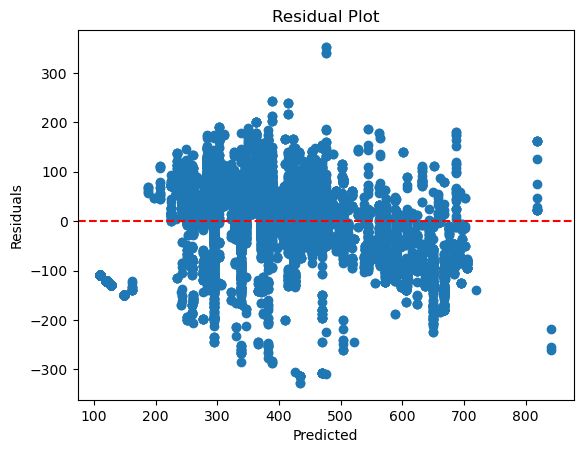

In [16]:
import matplotlib.pyplot as plt

residuals = y - y_pred

plt.scatter(y_pred, residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()

In [20]:
print(df['Transmission'].value_counts())

Transmission
Automatic (S8)                      3239
Automatic (S6)                      1479
Automatic (A1)                      1309
Manual 6-spd                        1103
Automatic 8-spd                     1029
Automatic 9-spd                      851
Automatic (AM-S7)                    765
Automatic (S10)                      732
Automatic (variable gear ratios)     644
Automatic 6-spd                      572
Automatic 10-spd                     513
Automatic (AM-S8)                    352
Automatic (S9)                       310
Automatic (AV-S6)                    284
Automatic (AM7)                      250
Automatic 7-spd                      239
Automatic (AV-S8)                    212
Automatic (AV-S7)                    204
Automatic (S7)                       198
Automatic (AM-S6)                    192
Manual 5-spd                         175
Manual 7-spd                         157
Automatic (A2)                       100
Automatic (AM8)                       91
Aut

In [22]:
# Search all string columns for 'v8' (case-insensitive)
mask = df.apply(lambda col: col.astype(str).str.contains('V8', case=False, na=False)).any(axis=1)
print(df[mask])

               Make                          Model  Year         Fuel_Type  \
46           Jaguar        F-Type V8 S Convertible  2015  Premium Gasoline   
204    Aston Martin                     V8 Vantage  2015  Premium Gasoline   
205    Aston Martin                   V8 Vantage S  2015  Premium Gasoline   
207    Aston Martin                     V8 Vantage  2015  Premium Gasoline   
208    Aston Martin                   V8 Vantage S  2015  Premium Gasoline   
2043   Aston Martin                     V8 Vantage  2016  Premium Gasoline   
2044   Aston Martin                   V8 Vantage S  2016  Premium Gasoline   
2046   Aston Martin                     V8 Vantage  2016  Premium Gasoline   
2047   Aston Martin                   V8 Vantage S  2016  Premium Gasoline   
3878       Maserati                Quattroporte V8  2018  Premium Gasoline   
5274   Aston Martin                     Vantage V8  2019  Premium Gasoline   
5288   Aston Martin                        DB11 V8  2019  Premiu